In [73]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def compute_loss(y_true, y_pred):
    m = y_true.shape[0]
    loss = - (1 / m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss
class LogisticRegression:
    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.learning_rate = learning_rate
        self.num_iterations = num_iterations
        self.weights = None
        self.bias = None
    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
        for i in range(self.num_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_predicted = sigmoid(linear_model)
            if i % 100 == 0:
                loss = compute_loss(y, y_predicted)
                print(f"Iteration {i}, Loss: {loss}")
            # Gradient descent
            dw = (1 / m) * np.dot(X.T, (y_predicted - y))
            db = (1 / m) * np.sum(y_predicted - y)
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
    def predict(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_predicted = sigmoid(linear_model)
        y_predicted_cls = [1 if i > 0.5 else 0 for i in y_predicted]
        return np.array(y_predicted_cls)

In [74]:
X = np.array([
    [0.9, 0.1],
    [0.8, 0.2],
    [0.7, 0.3], 
    [0.2, 0.8],
    [0.1, 0.9],
    [0.3, 0.7]   
])

y = np.array([1, 1, 1, 0, 0, 0])
# Create and train the logistic regression model
model = LogisticRegression(learning_rate=0.1, num_iterations=1000)
model.fit(X, y)

print("weights:", model.weights)
print("bias:", model.bias)
# Make predictions
pred = model.predict(X)
print("predictions:", pred)
print("actual:", y)
accu = np.mean(pred == y)
print("accuracy:", accu)
# Test on training data
test = np.array([[0.85, 0.15]])
test_pred = model.predict(test)
print("test prediction:", test_pred)

Iteration 0, Loss: 0.6931471805599452
Iteration 100, Loss: 0.40083871154749523
Iteration 200, Loss: 0.2735454384708429
Iteration 300, Loss: 0.20656913831444082
Iteration 400, Loss: 0.16599215784122673
Iteration 500, Loss: 0.13893038517126177
Iteration 600, Loss: 0.11962767556825149
Iteration 700, Loss: 0.10516865750203458
Iteration 800, Loss: 0.09392980501535975
Iteration 900, Loss: 0.0849385439708954
weights: [ 4.608604 -4.608604]
bias: -1.0963452368173423e-16
predictions: [1 1 1 0 0 0]
actual: [1 1 1 0 0 0]
accuracy: 1.0
test prediction: [1]


In [75]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [76]:
df = pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [77]:
df.shape

(5728, 2)

In [78]:
df.columns

Index(['text', 'spam'], dtype='str')

In [79]:
# Checking missing values
df.isnull().sum()

text    0
spam    0
dtype: int64

In [80]:
# Count how many emails are spam and how many are not
df['spam'].value_counts()

spam
0    4360
1    1368
Name: count, dtype: int64

In [81]:
from sklearn.model_selection import train_test_split
X = df['text']
y = df['spam']
# Split the dataset into traning and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create the TF-IDF vectorizer
# Remove commong English ex: this, is, a,...
vectorizer = TfidfVectorizer(stop_words='english')
# Learn the vocabulary from the training data and transform it into vectors
X_train_vec = vectorizer.fit_transform(X_train)
# Transform the test data using the same vocabulary
X_test_vec = vectorizer.transform(X_test)

In [83]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_vec, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [84]:
y_pred = model.predict(X_test_vec)

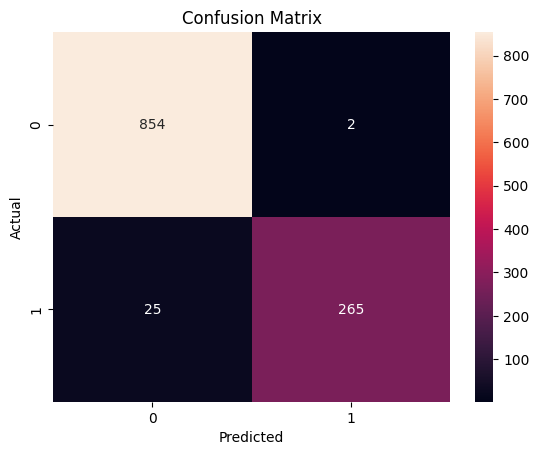

In [85]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
# Visualize confusion matrix using heatmap
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [86]:
new_email = ["Congratulations! You won a free ticket"]
new_vec = vectorizer.transform(new_email)
pred = model.predict(new_vec)
print("Spam" if pred[0] == 1 else "Not Spam")

Not Spam
